# Task 1.6: Analysis of resource permissions of the BPIC-17 event log

### Imports and Setup

In [510]:
import pm4py as pm
import pandas as pd

In [ ]:
log = pm.read_xes('../../data/BPI Challenge 2017.xes.gz')
df_raw = pm.convert_to_dataframe(log)

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [ ]:
df_whole = df_raw.copy()

In [ ]:
df_whole.rename(columns={
    'org:resource': 'Resource',
    'concept:name': 'Activity',
    'time:timestamp': 'Timestamp',
    'lifecycle:transition': 'State',
    'case:concept:name': 'Case'
}, inplace=True)
df_whole.drop(columns=['EventOrigin', 'EventID', 'case:LoanGoal', 'case:ApplicationType', 'case:RequestedAmount',
       'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost',
       'Selected', 'CreditScore', 'OfferedAmount', 'OfferID'], inplace=True)

df_whole['ResourceId'] = df_whole['Resource'].astype(str).str.lstrip('User_').astype(int)   # Used for sorting and quicker access
df_whole['Date'] = df_whole['Timestamp'].dt.date    # Needed for grouping
df_whole['Time'] = df_whole['Timestamp'].dt.time

In [ ]:
# Set sorting order
sorted_resources = df_whole.sort_values('ResourceId')['Resource'].drop_duplicates().tolist()
df_whole['Resource'] = pd.Categorical(df_whole['Resource'], categories=sorted_resources, ordered=True)

In [ ]:
df_filtered = df_whole[~df_whole['Activity'].isin(['W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection', 'O_Sent (online only)'])]     # Activities not in bpmn model
df_filtered = df_filtered[df_filtered['State'] == 'complete']  # Only take into account resources that completed the activity

In [ ]:
df = df_filtered
df

,Action,Resource,Activity,State,Timestamp,Case,ResourceId,Date,Time
0,Created,User_1,A_Create Application,complete,2016-01-01 09:51:15.304000+00:00,Application_652823628,1,2016-01-01,09:51:15.304000
1,statechange,User_1,A_Submitted,complete,2016-01-01 09:51:15.352000+00:00,Application_652823628,1,2016-01-01,09:51:15.352000
5,statechange,User_1,A_Concept,complete,2016-01-01 09:52:36.413000+00:00,Application_652823628,1,2016-01-01,09:52:36.413000
8,statechange,User_52,A_Accepted,complete,2016-01-02 11:23:04.299000+00:00,Application_652823628,52,2016-01-02,11:23:04.299000
9,Created,User_52,O_Create Offer,complete,2016-01-02 11:29:03.994000+00:00,Application_652823628,52,2016-01-02,11:29:03.994000
...,...,...,...,...,...,...,...,...,...
1202256,statechange,User_96,O_Sent (mail and online),complete,2017-01-02 19:27:20.453000+00:00,Application_1350494635,96,2017-01-02,19:27:20.453000
1202257,Deleted,User_96,W_Complete application,complete,2017-01-02 19:27:20.465000+00:00,Application_1350494635,96,2017-01-02,19:27:20.465000
1202260,statechange,User_96,A_Complete,complete,2017-01-02 19:27:20.474000+00:00,Application_1350494635,96,2017-01-02,19:27:20.474000
1202264,statechange,User_28,A_Cancelled,complete,2017-01-16 09:51:21.114000+00:00,Application_1350494635,28,2017-01-16,09:51:21.114000


## Basic Approach
Permissions based on whether a resource has processed an activity before at some point in the event log

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df_permissions = df[['Activity', 'Resource']].drop_duplicates()
df_permissions

,Activity,Resource
0,A_Create Application,User_1
1,A_Submitted,User_1
5,A_Concept,User_1
8,A_Accepted,User_52
9,O_Create Offer,User_52
...,...,...
1189778,A_Create Application,User_105
1190708,W_Call after offers,User_77
1193556,W_Validate application,User_105
1193559,A_Incomplete,User_105


Visualise Results

In [ ]:
def plot_permissions_matrix(activity_matrix, name, scale_size=1):
    df_long = activity_matrix.reset_index().melt(
        id_vars='Resource', 
        var_name='Activity', 
        value_name='Frequency'
    )
    df_long = df_long[df_long['Frequency'] > 0]
    df_long = df_long.sort_values('Resource')

    fig = plt.figure(figsize=(24, 8))
    plt.scatter(
        x=df_long['Resource'], 
        y=df_long['Activity'], 
        s=df_long['Frequency'] * scale_size,  
        alpha=0.8,           
        c='tab:blue',        
        edgecolors='white',  
        linewidth=0.5
    )

    plt.title(f"Resource-Activity Matrix {name}", fontsize=16, pad=20)
    plt.xlabel("Resource", fontsize=12, labelpad=10)
    plt.ylabel("Activity", fontsize=12, labelpad=10)

    plt.xticks(
    ticks=range(144), 
    labels=sorted_resources[:144],
    rotation=90, 
    fontsize=9
    )
    plt.yticks(fontsize=10)

    plt.margins(x=0.02)
    plt.grid(True, linestyle='--', alpha=0.3, zorder=0)
    plt.tight_layout()
    return fig

/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_27095/4021932502.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()
/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_27095/4021932502.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


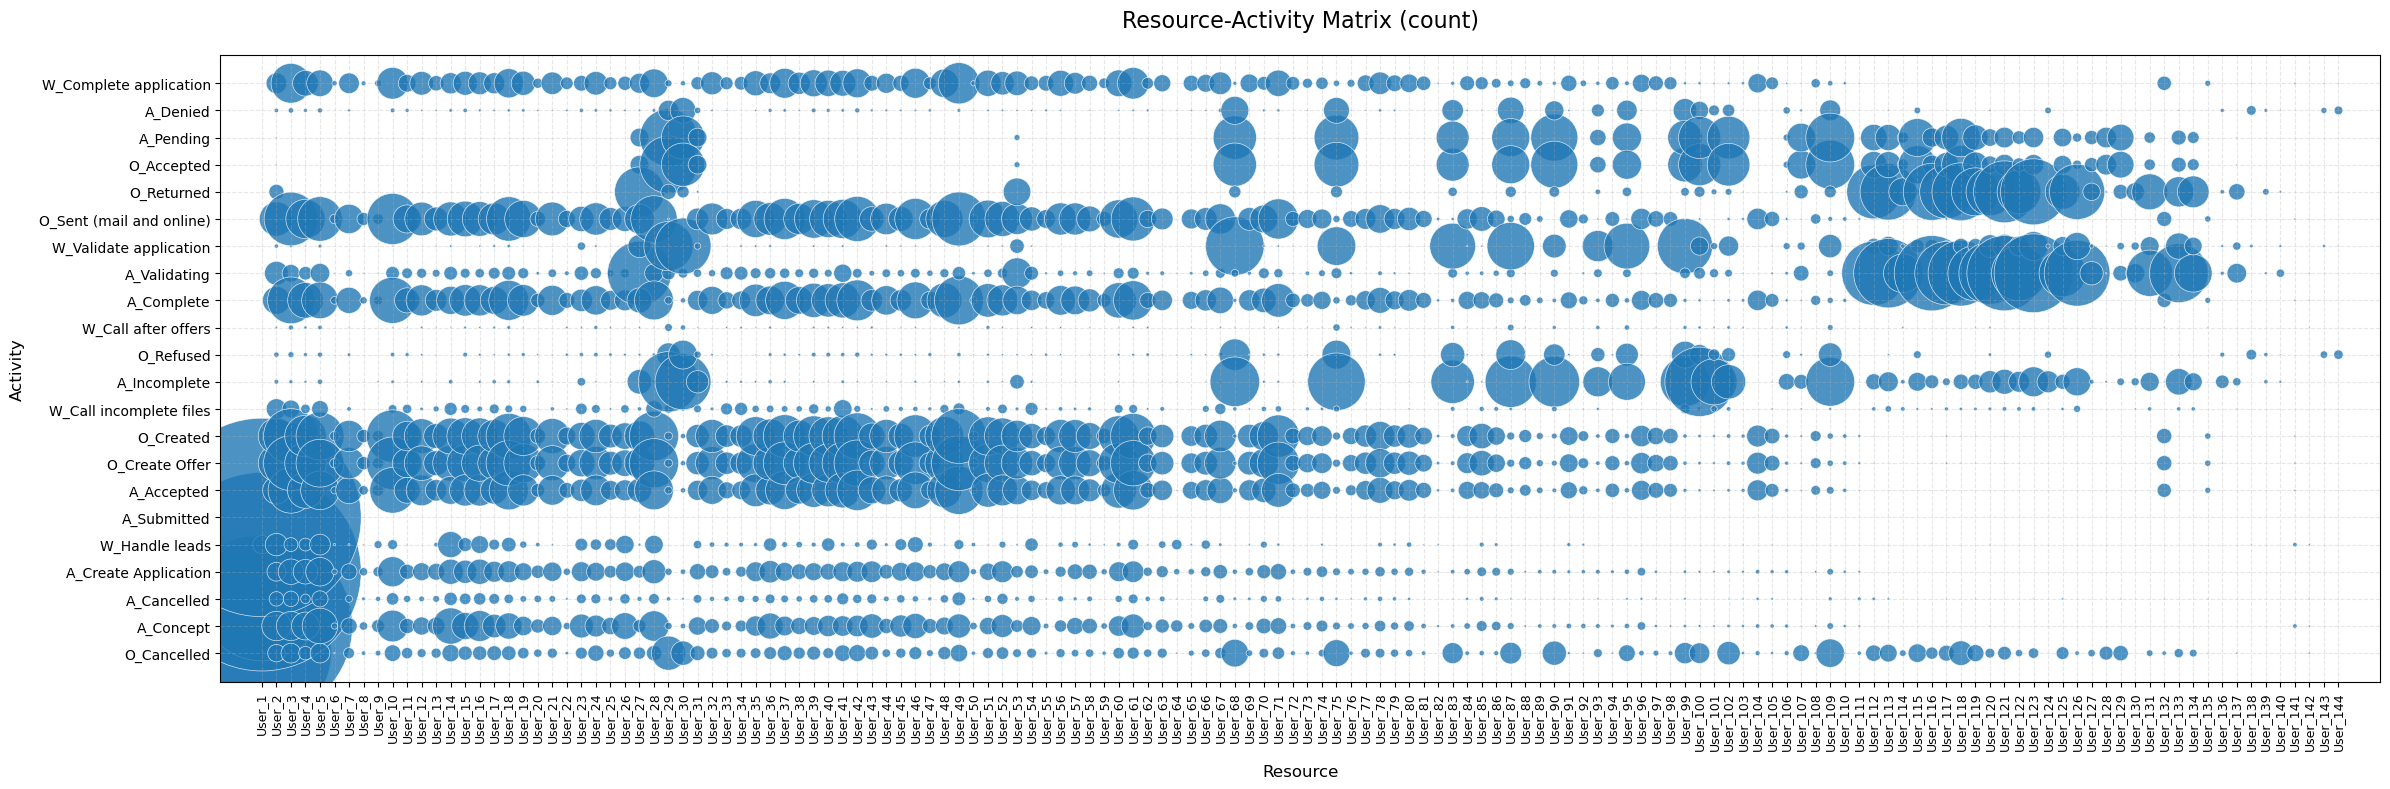

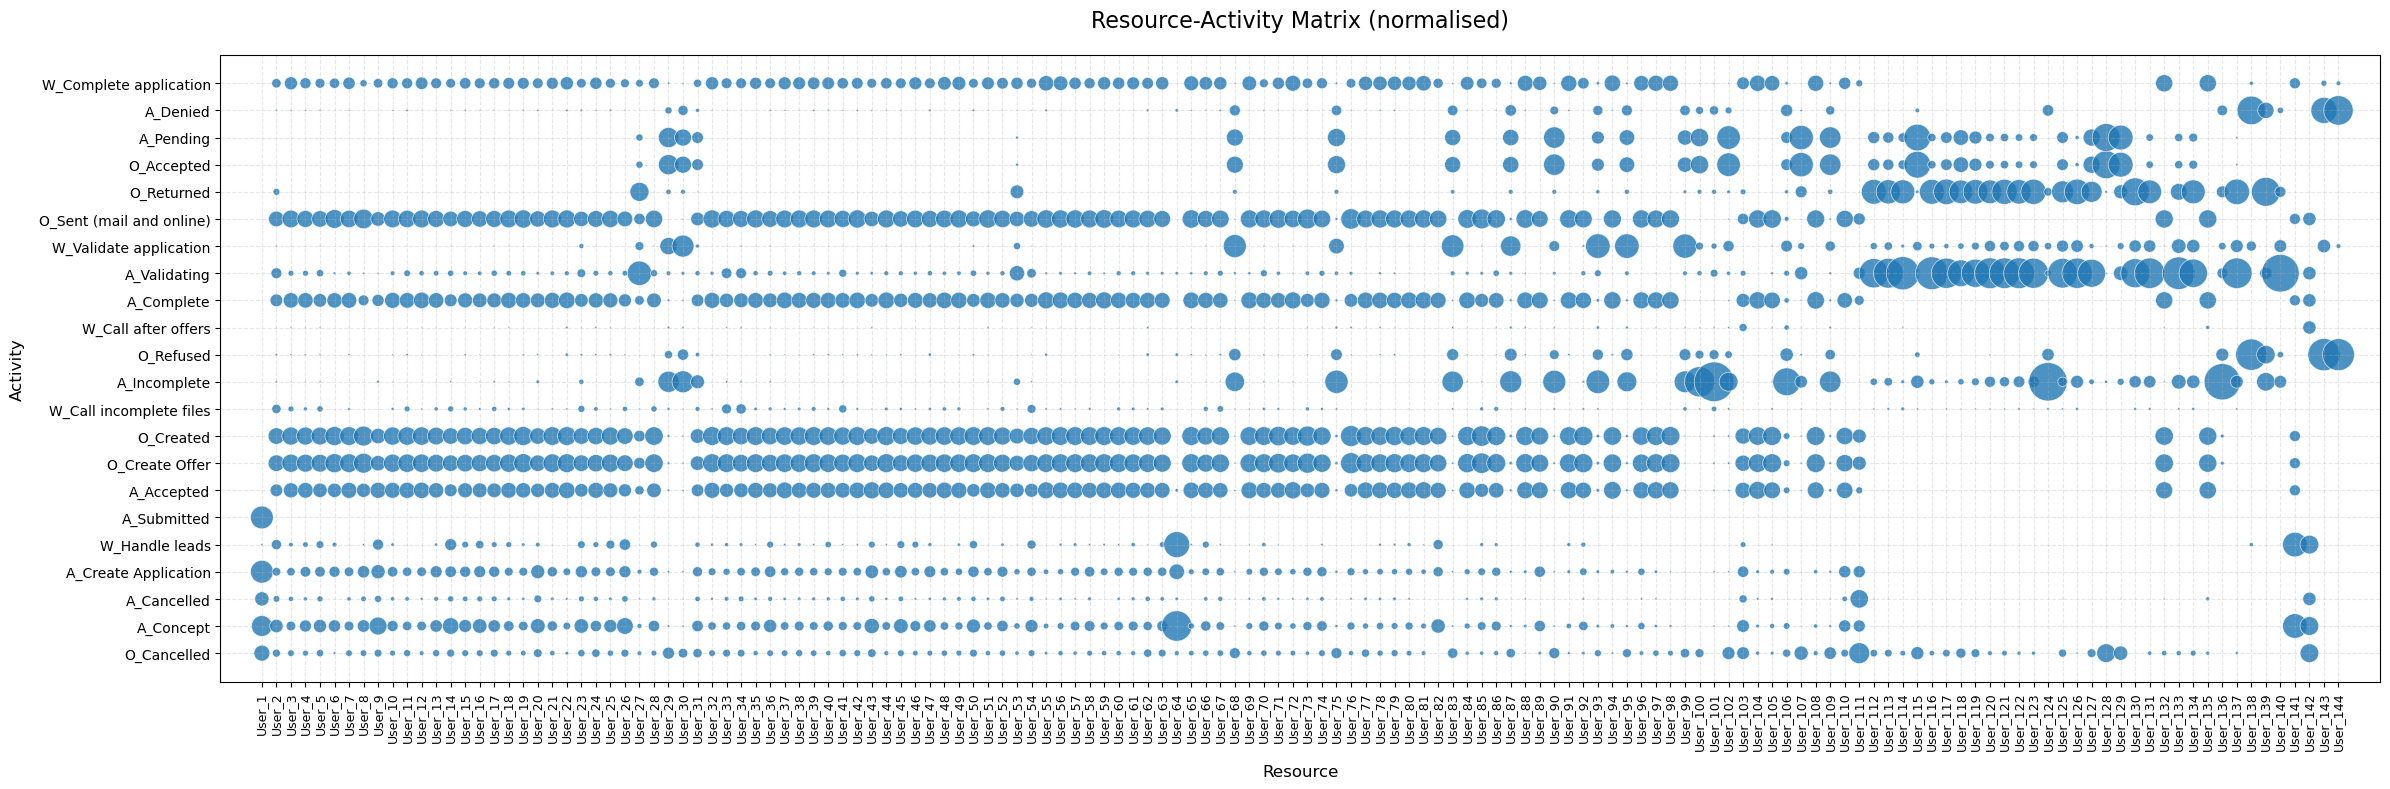

In [ ]:
activity_matrix = pd.crosstab(df['Resource'], df['Activity'])
plot = plot_permissions_matrix(activity_matrix, "(count)")
plot.savefig("files/permissions_matrix_count.pdf", format='pdf', bbox_inches='tight')
plot.show()
activity_matrix = activity_matrix.div(activity_matrix.sum(axis=1), axis=0)
plot = plot_permissions_matrix(activity_matrix, "(normalised)", 1000)
plot.savefig("files/permissions_matrix_normalised.pdf", format='pdf', bbox_inches='tight')
plot.show()

In [ ]:
df_permissions.to_csv('permissions_basic.csv', index=False)
print("Created 'permissions_basic.csv'")
df_permissions

Created 'permissions_basic.csv'


,Activity,Resource
0,A_Create Application,User_1
1,A_Submitted,User_1
5,A_Concept,User_1
8,A_Accepted,User_52
9,O_Create Offer,User_52
...,...,...
1189778,A_Create Application,User_105
1190708,W_Call after offers,User_77
1193556,W_Validate application,User_105
1193559,A_Incomplete,User_105


#### Tests

In [ ]:
grouped = df_permissions.groupby('Activity')['Resource'].unique()
grouped


Activity
A_Accepted                  ['User_52', 'User_38', 'User_19', 'User_17', '...
A_Cancelled                 ['User_1', 'User_27', 'User_8', 'User_112', 'U...
A_Complete                  ['User_52', 'User_38', 'User_19', 'User_17', '...
A_Concept                   ['User_1', 'User_17', 'User_38', 'User_3', 'Us...
A_Create Application        ['User_1', 'User_17', 'User_38', 'User_3', 'Us...
A_Denied                    ['User_68', 'User_99', 'User_95', 'User_29', '...
A_Incomplete                ['User_115', 'User_101', 'User_114', 'User_95'...
A_Pending                   ['User_115', 'User_90', 'User_95', 'User_119',...
A_Submitted                 ['User_1']
Categories (149, object): ['User_1'...
A_Validating                ['User_117', 'User_119', 'User_116', 'User_31'...
O_Accepted                  ['User_115', 'User_90', 'User_95', 'User_119',...
O_Cancelled                 ['User_19', 'User_95', 'User_1', 'User_27', 'U...
O_Create Offer              ['User_52', 'User_38', 'Use

In [ ]:
df_permissions[df_permissions['Resource'] == 'User_1']

,Activity,Resource
0,A_Create Application,User_1
1,A_Submitted,User_1
5,A_Concept,User_1
218,A_Cancelled,User_1
219,O_Cancelled,User_1
6549,W_Handle leads,User_1


## Advanced Approach
Based on OrdinoR Framework

In [ ]:
df_adv = df[df['Resource'] != 'User_1'].copy()     # Remove User_1 since it is likely a system and not human based on availabilities analysis

### Construct feature matrix with multiple dimensions

In [ ]:
def view_freq_matrix(freq_matrix):
    return freq_matrix.style.background_gradient(
    cmap='YlGnBu', 
    axis=None
).format("{:.2%}")

Activity Dimension

In [ ]:
activity_matrix = pd.crosstab(df_adv['Resource'], df_adv['Activity'])
activity_matrix = activity_matrix.div(activity_matrix.sum(axis=1), axis=0)  # normalise

In [ ]:
freq_act = view_freq_matrix(activity_matrix)
freq_act.to_html("files/frequency_matrix_activity.html")
print("Created 'frequency_matrix_activity.html'")

Created 'frequency_matrix_activity.html'


Time Dimension

In [ ]:
df_adv['Hour'] = df_adv['Timestamp'].dt.hour
df_adv['Shift'] = pd.cut(   # Find same time shifts for resources working together
    df_adv['Hour'],
    bins=[-1, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

time_matrix = pd.crosstab(df_adv['Resource'], df_adv['Shift'])
time_matrix = time_matrix.div(time_matrix.sum(axis=1), axis=0)

In [ ]:
freq_time = view_freq_matrix(time_matrix)
freq_time.to_html("files/frequency_matrix_time.html")
print("Created 'frequency_matrix_time.html'")

Created 'frequency_matrix_time.html'


Case Dimension

In [ ]:
# Manual Calculation
case_res = df_adv[['Case', 'Resource']].drop_duplicates()
case_merged = pd.merge(case_res, case_res, on='Case')
case_merged = case_merged[case_merged['Resource_x'] != case_merged['Resource_y']]

case_matrix = pd.crosstab(case_merged['Resource_x'], case_merged['Resource_y'])
case_matrix = case_matrix.div(case_matrix.sum(axis=1), axis=0)

# Sort matrix to compare to Pm4Py version later
case_matrix.sort_index(
    key=lambda x : x.str.split('_').str[1].astype(int),
    inplace=True)
case_matrix.sort_index(
    axis=1,
    key=lambda x : x.str.split('_').str[1].astype(int),
    inplace=True)

In [ ]:
freq_case = view_freq_matrix(case_matrix)
freq_case.to_html("files/frequency_matrix_case.html")
print("Created 'frequency_matrix_case.html'")

Created 'frequency_matrix_case.html'


In [ ]:
feature_matrix = pd.concat([activity_matrix, time_matrix, case_matrix], axis=1).fillna(0)
feature_matrix.shape

(143, 168)

### Apply Hierarchical Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
def get_optimal_k(matrix):
    print("Finding optimal k")
    best_k = 2
    best_score = -1
    
    for k in range(2, 11):
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(matrix)
        score = silhouette_score(matrix, labels)
        print(f"k={k}: Silhouette Score = {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_k = k
            
    print(f"Optimal clusters: {best_k} (Score: {best_score:.4f})\n")
    return best_k

def view_dendrogram(matrix, Z, name):
    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=matrix.index, leaf_rotation=90)
    plt.title(f"Dendrogram {name}")
    plt.xlabel("Resources")
    plt.ylabel("Distance")
    plt.savefig(f"files/dendrogram_{name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [ ]:
user_1 = pd.DataFrame([{'Resource': 'User_1', 'Role': 'Role_0'}])   # Add user_1 after clustering

Activity matrix only

Finding optimal k
k=2: Silhouette Score = 0.6101
k=3: Silhouette Score = 0.7018
k=4: Silhouette Score = 0.7279
k=5: Silhouette Score = 0.7365
k=6: Silhouette Score = 0.7424
k=7: Silhouette Score = 0.7391
k=8: Silhouette Score = 0.4749
k=9: Silhouette Score = 0.4702
k=10: Silhouette Score = 0.4688
Optimal clusters: 6 (Score: 0.7424)



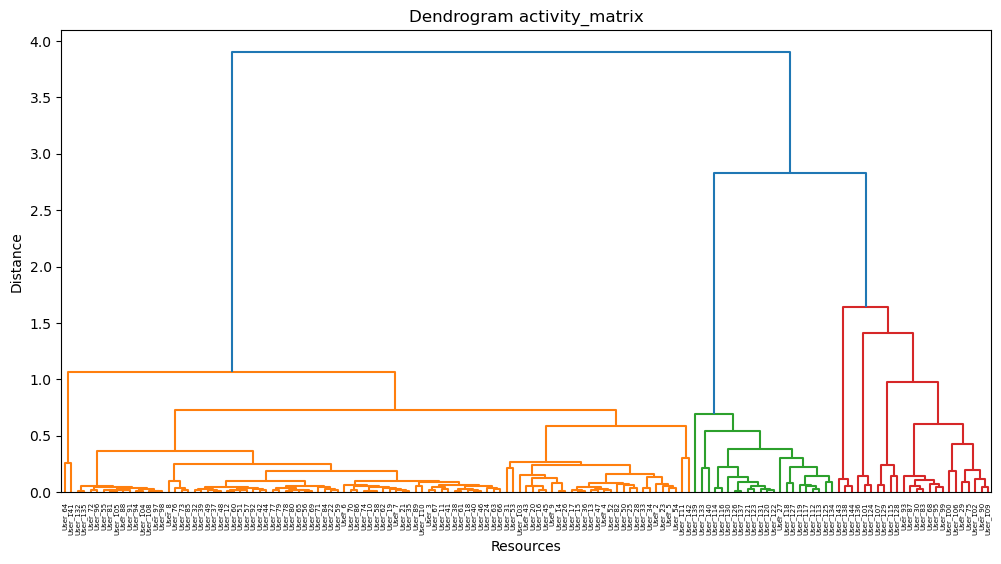

In [ ]:
k_act = get_optimal_k(activity_matrix)
Z_act = linkage(activity_matrix, method='ward', metric='euclidean')
view_dendrogram(activity_matrix, Z_act, 'activity_matrix')

In [ ]:
model = AgglomerativeClustering(n_clusters=k_act, linkage='ward')
clusters_act = model.fit_predict(activity_matrix)

In [ ]:
# Save roles
resource_roles_act = pd.DataFrame({
    'Resource': activity_matrix.index, 
    'Role': [f'Role_{c + 1}' for c in clusters_act]
})
print(resource_roles_act['Role'].value_counts())

Role
Role_2    95
Role_3    22
Role_1    18
Role_5     3
Role_4     3
Role_6     2
Name: count, dtype: int64


In [ ]:
resource_roles_act = pd.concat([resource_roles_act, user_1], ignore_index=True)
resource_roles_act.to_csv('files/resource_roles_act.csv', index=False)
print("Created 'resource_roles_act.csv'")

Created 'resource_roles_act.csv'


Feature Matrix

Finding optimal k
k=2: Silhouette Score = 0.4796
k=3: Silhouette Score = 0.5439
k=4: Silhouette Score = 0.5504
k=5: Silhouette Score = 0.5658
k=6: Silhouette Score = 0.3182
k=7: Silhouette Score = 0.3283
k=8: Silhouette Score = 0.3353
k=9: Silhouette Score = 0.3196
k=10: Silhouette Score = 0.3179
Optimal clusters: 5 (Score: 0.5658)



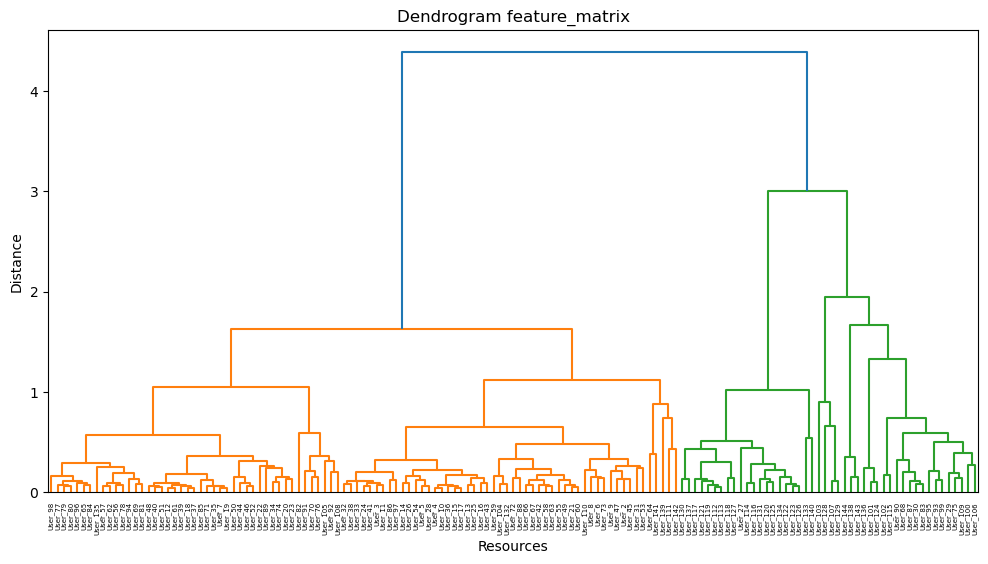

In [ ]:
k_feature = get_optimal_k(feature_matrix)
Z = linkage(feature_matrix, method='ward', metric='euclidean')
view_dendrogram(feature_matrix, Z, 'feature_matrix')

In [ ]:
model = AgglomerativeClustering(n_clusters=k_feature, linkage='ward')
clusters_feat = model.fit_predict(feature_matrix)

In [ ]:
resource_roles_feat = pd.DataFrame({
    'Resource': feature_matrix.index,
    'Role': [f'Role_{c + 1}' for c in clusters_feat]
})
print(resource_roles_feat['Role'].value_counts())

Role
Role_1    97
Role_3    21
Role_2    18
Role_4     4
Role_5     3
Name: count, dtype: int64


In [ ]:
resource_roles_feat = pd.concat([resource_roles_feat, user_1], ignore_index=True)     # Add User_1
resource_roles_feat.to_csv('files/resource_roles_feat.csv', index=False)
print("Created 'resource_roles_feat.csv'")

#### Compare feat and act matrix roles

In [ ]:
def get_role_matrix(resource_roles, name):
    df_merged = pd.merge(df_filtered, resource_roles, on='Resource')
    role_act_count = pd.crosstab(df_merged['Role'], df_merged['Activity'])
    role_act_freq = role_act_count.div(role_act_count.sum(axis=1), axis=0)
    freq = view_freq_matrix(role_act_freq)
    freq.to_html(f"files/role_frequency_matrix_{name}.html")
    print(f"Created 'role_frequency_matrix_{name}.html'")
    return freq

In [ ]:
get_role_matrix(resource_roles_act, 'act')

Created 'role_frequency_matrix_act.html'


Activity,A_Accepted,A_Cancelled,A_Complete,A_Concept,A_Create Application,A_Denied,A_Incomplete,A_Pending,A_Submitted,A_Validating,O_Accepted,O_Cancelled,O_Create Offer,O_Created,O_Refused,O_Returned,O_Sent (mail and online),W_Call after offers,W_Call incomplete files,W_Complete application,W_Handle leads,W_Validate application
Role,,,,,,,,,,,,,,,,,,,,,,
Role_0,0.00%,10.47%,0.00%,22.38%,26.89%,0.00%,0.00%,0.00%,26.89%,0.00%,0.00%,13.14%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.23%,0.00%
Role_1,0.30%,0.07%,0.27%,0.29%,0.29%,4.52%,24.41%,18.54%,0.00%,1.22%,18.54%,6.10%,0.32%,0.32%,5.72%,1.41%,0.14%,0.25%,0.27%,0.22%,0.00%,16.82%
Role_2,12.44%,0.97%,12.39%,5.67%,4.33%,0.13%,0.24%,0.08%,0.00%,1.66%,0.08%,2.03%,16.98%,16.98%,0.14%,0.21%,15.72%,0.06%,0.97%,7.52%,1.30%,0.11%
Role_3,0.40%,0.03%,0.43%,0.12%,0.11%,0.02%,4.87%,5.13%,0.00%,45.30%,5.13%,2.03%,0.65%,0.65%,0.03%,29.19%,0.62%,0.01%,0.23%,0.28%,0.01%,4.76%
Role_4,0.00%,0.00%,0.00%,0.00%,0.00%,41.57%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,52.16%,0.00%,0.00%,0.00%,0.00%,1.18%,0.39%,4.71%
Role_5,0.16%,0.00%,0.11%,0.16%,0.16%,4.94%,79.31%,0.00%,0.00%,3.13%,0.00%,0.00%,0.27%,0.27%,5.82%,2.14%,0.00%,0.11%,1.21%,0.11%,0.00%,2.09%
Role_6,1.55%,0.52%,1.04%,45.08%,10.36%,0.52%,0.52%,0.00%,0.00%,0.52%,0.00%,1.04%,1.04%,1.04%,0.52%,0.00%,1.04%,0.00%,0.00%,1.04%,34.20%,0.00%


In [ ]:
get_role_matrix(resource_roles_feat, 'feat')

Created 'role_frequency_matrix_feat.html'


Activity,A_Accepted,A_Cancelled,A_Complete,A_Concept,A_Create Application,A_Denied,A_Incomplete,A_Pending,A_Submitted,A_Validating,O_Accepted,O_Cancelled,O_Create Offer,O_Created,O_Refused,O_Returned,O_Sent (mail and online),W_Call after offers,W_Call incomplete files,W_Complete application,W_Handle leads,W_Validate application
Role,,,,,,,,,,,,,,,,,,,,,,
Role_0,0.00%,10.47%,0.00%,22.38%,26.89%,0.00%,0.00%,0.00%,26.89%,0.00%,0.00%,13.14%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.23%,0.00%
Role_1,12.43%,0.96%,12.38%,5.70%,4.33%,0.13%,0.24%,0.08%,0.00%,1.66%,0.08%,2.03%,16.96%,16.96%,0.15%,0.21%,15.71%,0.06%,0.97%,7.52%,1.33%,0.11%
Role_2,0.31%,0.06%,0.27%,0.29%,0.29%,4.73%,26.71%,17.43%,0.00%,0.97%,17.43%,5.69%,0.33%,0.33%,5.97%,1.18%,0.15%,0.25%,0.30%,0.22%,0.00%,17.09%
Role_3,0.40%,0.03%,0.43%,0.12%,0.11%,0.01%,4.86%,5.13%,0.00%,45.32%,5.13%,2.04%,0.65%,0.65%,0.02%,29.18%,0.62%,0.01%,0.23%,0.28%,0.01%,4.77%
Role_4,0.32%,0.13%,0.25%,0.19%,0.16%,0.13%,4.61%,32.08%,0.00%,7.97%,32.08%,11.75%,0.35%,0.35%,0.13%,6.99%,0.16%,0.10%,0.06%,0.19%,0.03%,1.97%
Role_5,0.00%,0.00%,0.00%,0.00%,0.00%,41.57%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,52.16%,0.00%,0.00%,0.00%,0.00%,1.18%,0.39%,4.71%


- Application Creation or direct Cancellation: Role 0 (same)
- Offer Creation: Role 2 (act) == Role 1 (feat)
- Validation of Application esp. Incomplete Application Handling: Role 1 (act) == Role 2 (feat)
- Validation and Offer Return Validation: Role 3 (same)
- Finalisation of Application: Role 4 (feat)
- Refusal/Denying: Role 4 (act) == Role_5 (feat)

In activity matrix: Specialist for Handle leads and Incomplete Files => not necessary in the model




In [ ]:
resource_roles = resource_roles_feat
resource_roles.to_csv('resource_roles.csv', index=False)
print("Created 'resource_roles.csv'")
resource_roles

Created 'resource_roles.csv'


,Resource,Role
0,User_2,Role_1
1,User_3,Role_1
2,User_4,Role_1
3,User_5,Role_1
4,User_6,Role_1
...,...,...
139,User_141,Role_1
140,User_142,Role_1
141,User_143,Role_5
142,User_144,Role_5


Visualise discovered roles

In [ ]:
from matplotlib.lines import Line2D

In [ ]:
def plot_permissions_matrix_roles(activity_matrix, name, df_roles, scale_size=1):
    df_long = activity_matrix.reset_index().melt(
        id_vars='Resource', 
        var_name='Activity', 
        value_name='Frequency'
    )
    df_long = df_long[df_long['Frequency'] > 0]
    df_long = df_long.sort_values('Resource')
    df_long = df_long.merge(df_roles, on='Resource', how='left')

    unique_roles = df_long['Role'].dropna().unique()
    cmap = plt.get_cmap('tab10') 
    role_color_map = {role: cmap(i % 10) for i, role in enumerate(unique_roles)}
    df_long['Colour'] = df_long['Role'].map(role_color_map)

    fig = plt.figure(figsize=(24, 8))
    plt.scatter(
        x=df_long['Resource'], 
        y=df_long['Activity'], 
        s=df_long['Frequency'] * scale_size,  
        alpha=0.8,           
        c=df_long['Colour'],        
        edgecolors='white',  
        linewidth=0.5
    )

    plt.title(f"Resource-Activity Matrix {name}", fontsize=16, pad=20)
    plt.xlabel("Resource", fontsize=12, labelpad=10)
    plt.ylabel("Activity", fontsize=12, labelpad=10)

    plt.xticks(
    ticks=range(144), 
    labels=sorted_resources[:144],
    rotation=90, 
    fontsize=9
    )
    plt.yticks(fontsize=10)

    plt.margins(x=0.02)
    plt.grid(True, linestyle='--', alpha=0.3, zorder=0)

    legend = [Line2D([0], [0], marker='o', color='w', label=role, markerfacecolor=color, markersize=12, alpha=0.6) for role, color in role_color_map.items()]
    plt.legend(handles=legend, title="Roles", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    return fig

/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_27095/3245691228.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()
/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_27095/3245691228.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


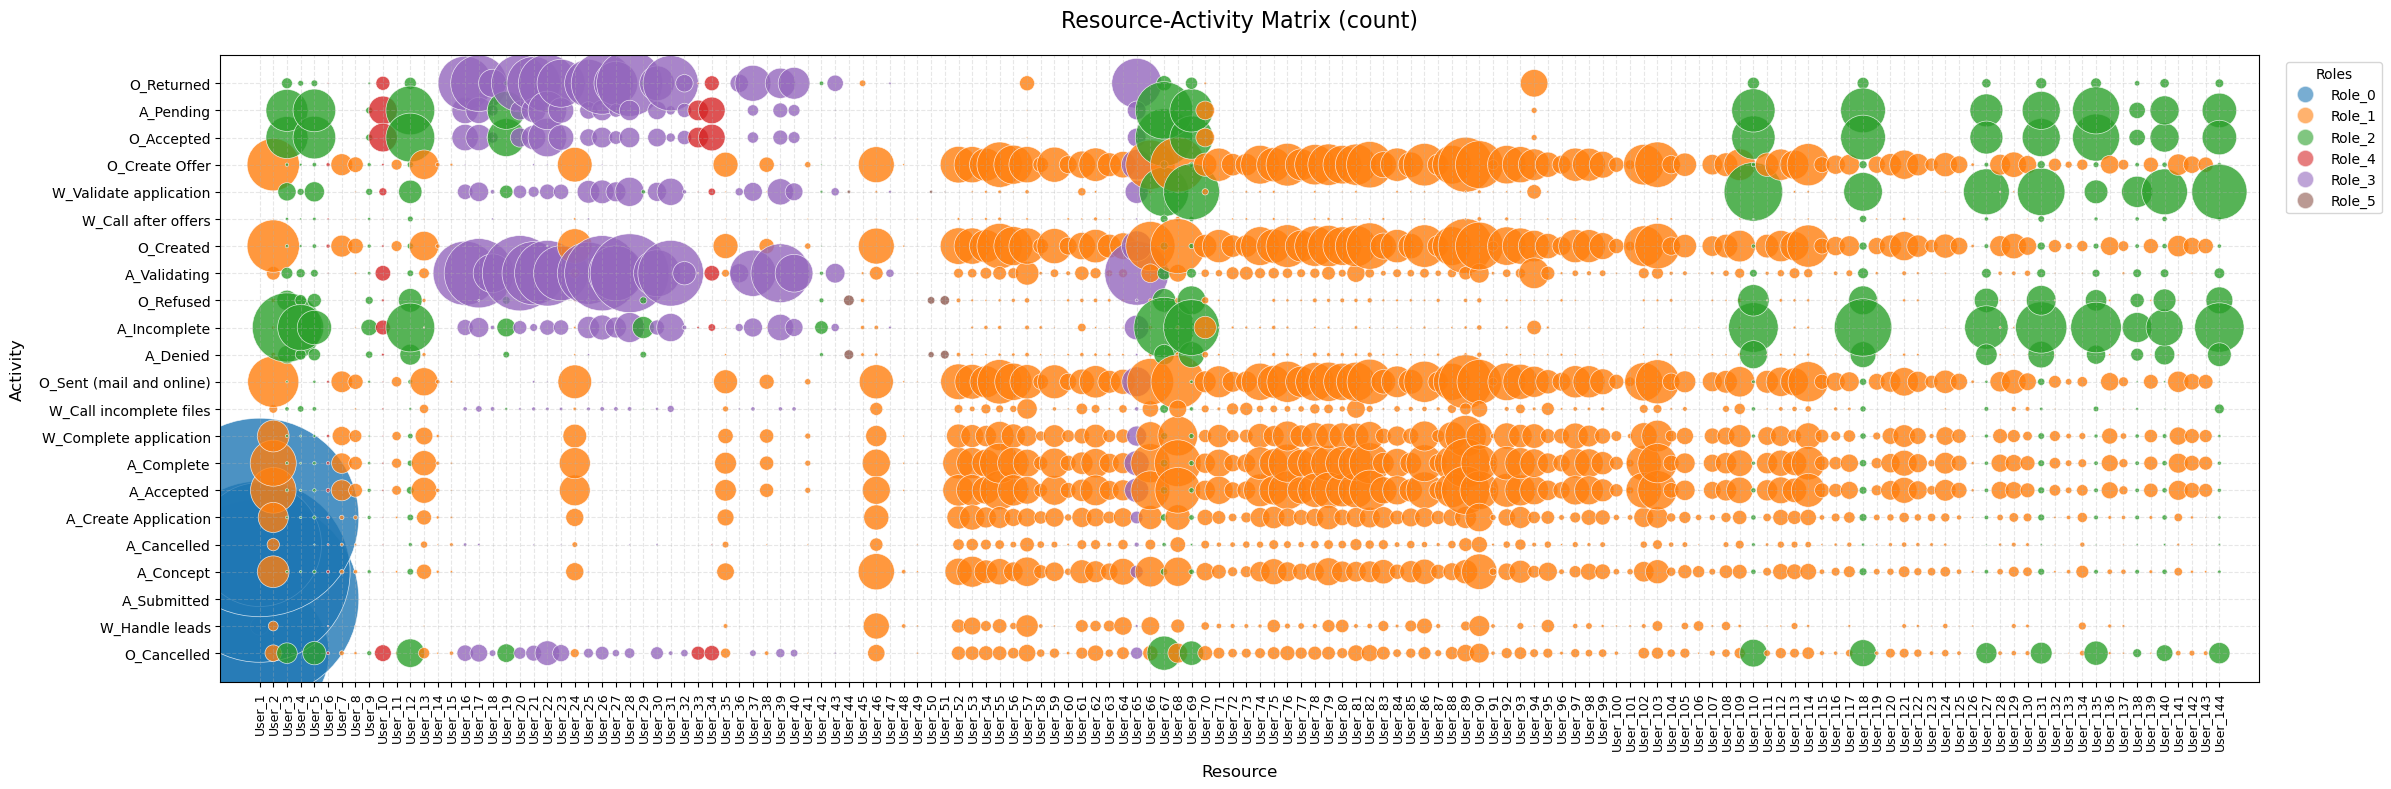

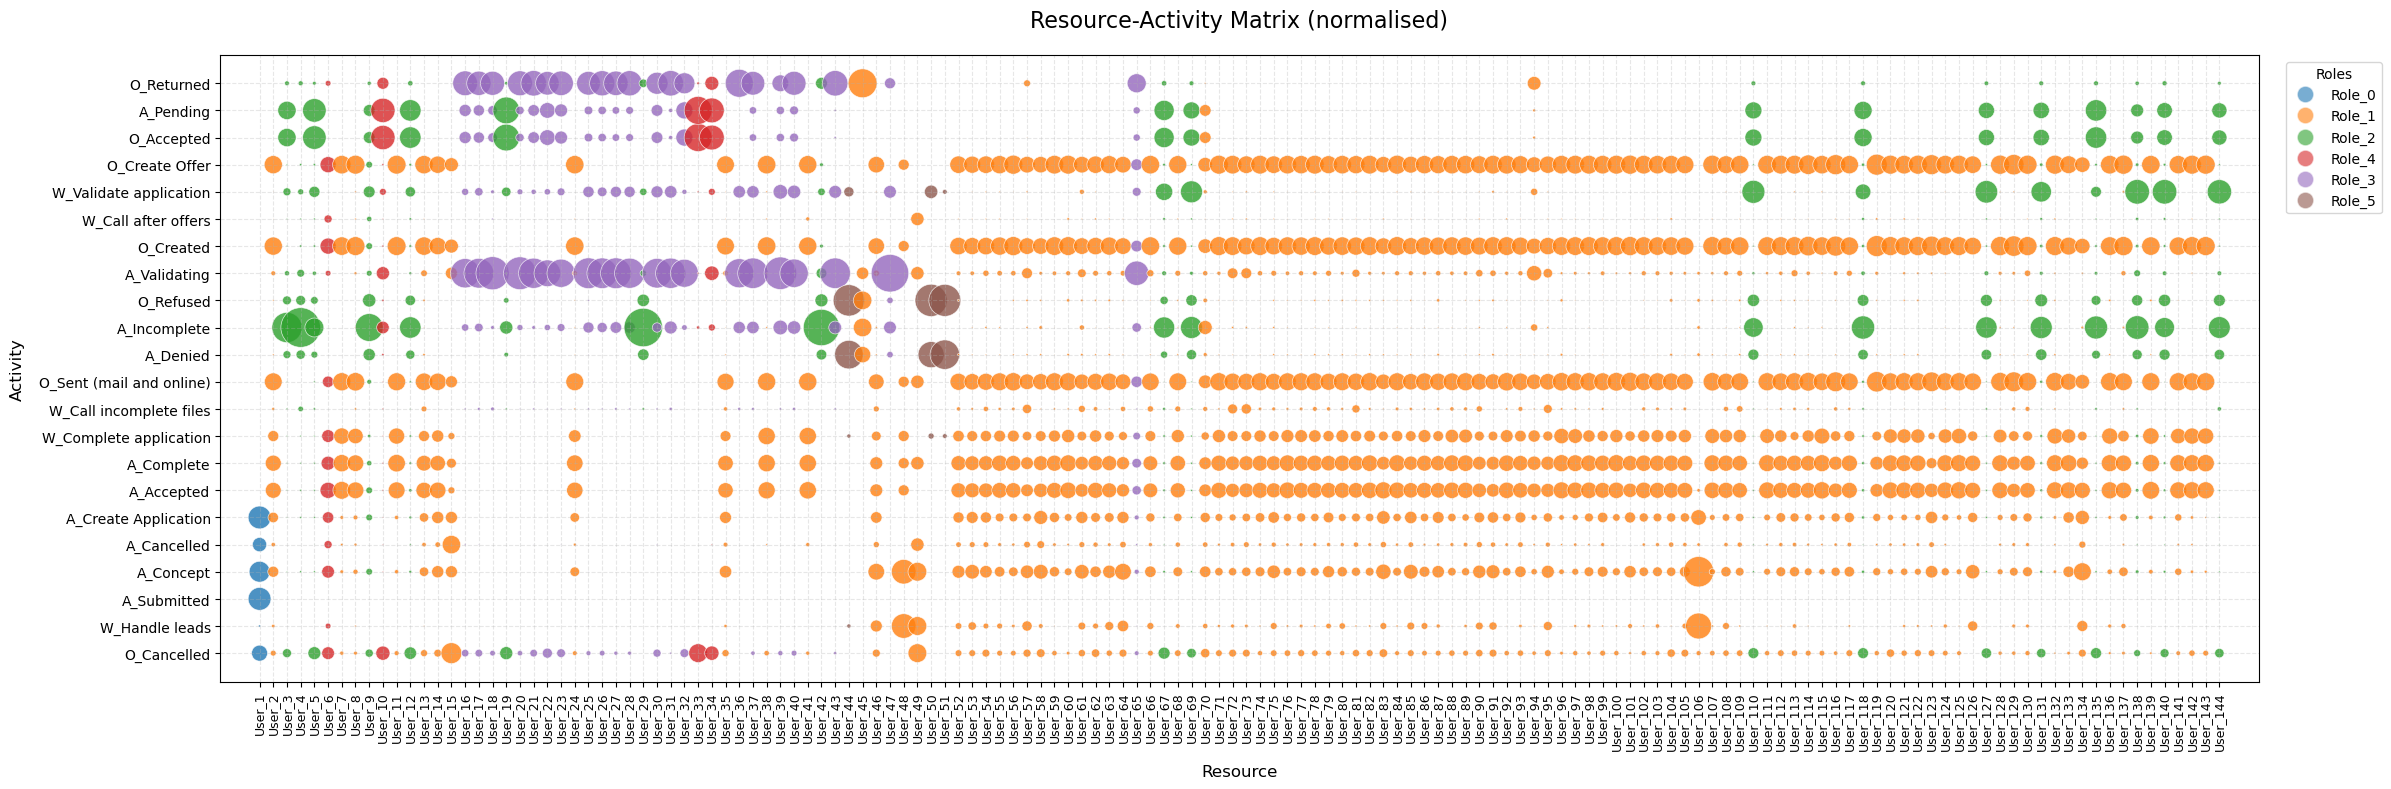

In [ ]:
df_merged = pd.merge(df, resource_roles, on='Resource')
activity_matrix = pd.crosstab(df_merged['Resource'], df_merged['Activity'])
plot = plot_permissions_matrix_roles(activity_matrix, "(count)", resource_roles)
plot.savefig("files/permissions_matrix_count_roles.pdf", format='pdf', bbox_inches='tight')
plot.show()

activity_matrix = activity_matrix.div(activity_matrix.sum(axis=1), axis=0)
plot = plot_permissions_matrix_roles(activity_matrix, "(normalised)", resource_roles, 1000)
plot.savefig("files/permissions_matrix_normalised_with_roles.pdf", format='pdf', bbox_inches='tight')
plot.show()

### Role Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

Define evaluation metrics

In [ ]:
def calculate_fitness(log, perms):
    total_events = len(log)
    conforming_events = 0
    role_allowed_acts = (perms.groupby('Role')['Activity'].apply(set).to_dict())   # faster lookup

    for _, row in log.iterrows():
        act = row['Activity']
        role = row['Role']
        if role in role_allowed_acts and act in role_allowed_acts[role]: # Role can do activity
            conforming_events += 1
    
    return conforming_events / total_events if total_events > 0 else 0


def calculate_precision(log, df_roles, perms):
    role_to_resources = df_roles.groupby('Role')['Resource'].apply(set).to_dict()
    act_to_roles = perms.groupby('Activity')['Role'].apply(set).to_dict()

    # Candidate resources for each activity
    cand_resources_act = {}
    for act, roles in act_to_roles.items():
        candidates = set()
        for role in roles:
            if role in role_to_resources:
                candidates.update(role_to_resources[role])
        cand_resources_act[act] = candidates

    all_candidate_resources = set()
    for act in log['Activity'].unique():
        candidates = cand_resources_act.get(act, set())
        all_candidate_resources.update(candidates)
    
    precisions = []

    for _, event in log.iterrows():
        act = event['Activity']
        res = event['Resource']
        cand = cand_resources_act.get(act, set())

        if len(cand) > 0:
            if res in cand:  # Conforming
                event_precision = (len(all_candidate_resources) - len(cand) + 1.0) / len(all_candidate_resources)
            else:
                event_precision = 0.0
                
            precisions.append(event_precision)

    if len(precisions) == 0:
        return 0.0
    
    return sum(precisions) / len(precisions) if precisions else 0


def calculate_f1_score(fitness, precision):
    if fitness + precision == 0:
        return 0
    return 2 * (fitness * precision) / (fitness + precision)


def evaluate_model(df_merged, df_roles, threshold):
    print(f"\n--- Evaluating Model (Threshold: {threshold * 100}%) ---")
    role_act_count = pd.crosstab(df_merged['Role'], df_merged['Activity'])
    role_act_freq = role_act_count.div(role_act_count.sum(axis=1), axis=0)

    role_permissions = (
        (role_act_freq > threshold)
        .stack()
        .loc[lambda x: x]
        .reset_index()[['Role', 'Activity']]
    )

    fit = calculate_fitness(df_merged, role_permissions)
    prec = calculate_precision(df_merged, df_roles, role_permissions)
    f1 = calculate_f1_score(fit, prec)
    
    print(f"Fitness:   {fit:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return fit, prec, f1


Evaluate scores on log data

In [ ]:
df_merged = pd.merge(df_filtered, resource_roles, on='Resource')   # Add roles to log

train_cases, test_cases = train_test_split(df_merged['Case'].unique(), test_size=0.3, random_state=42)
train_log = df_merged[df_merged['Case'].isin(train_cases)]
test_log = df_merged[df_merged['Case'].isin(test_cases)]

role_act_count = pd.crosstab(train_log['Role'], train_log['Activity'])
role_act_count

Activity,A_Accepted,A_Cancelled,A_Complete,A_Concept,A_Create Application,A_Denied,A_Incomplete,A_Pending,A_Submitted,A_Validating,...,O_Create Offer,O_Created,O_Refused,O_Returned,O_Sent (mail and online),W_Call after offers,W_Call incomplete files,W_Complete application,W_Handle leads,W_Validate application
Role,,,,,,,,,,,,,,,,,,,,,
Role_0,0,5583,0,11888,14241,0,0,0,14241,0,...,0,0,0,0,0,0,0,0,107,0
Role_1,21687,1691,21583,9953,7605,231,431,139,0,2955,...,29582,29582,254,378,27372,108,1735,13142,2273,180
Role_2,154,31,134,149,149,2315,13092,8544,0,477,...,161,161,2932,577,65,126,156,111,0,8342
Role_3,208,21,227,62,58,7,2514,2639,0,23593,...,346,346,10,15192,328,5,124,142,4,2464
Role_4,7,2,5,4,3,4,112,715,0,178,...,8,8,4,151,4,2,2,4,1,46
Role_5,0,0,0,0,0,74,0,0,0,0,...,0,0,96,0,0,0,0,1,1,10


In [ ]:
role_act_freq = role_act_count.div(role_act_count.sum(axis=1), axis=0)
view_freq_matrix(role_act_freq)

Activity,A_Accepted,A_Cancelled,A_Complete,A_Concept,A_Create Application,A_Denied,A_Incomplete,A_Pending,A_Submitted,A_Validating,O_Accepted,O_Cancelled,O_Create Offer,O_Created,O_Refused,O_Returned,O_Sent (mail and online),W_Call after offers,W_Call incomplete files,W_Complete application,W_Handle leads,W_Validate application
Role,,,,,,,,,,,,,,,,,,,,,,
Role_0,0.00%,10.52%,0.00%,22.40%,26.84%,0.00%,0.00%,0.00%,26.84%,0.00%,0.00%,13.19%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.20%,0.00%
Role_1,12.42%,0.97%,12.36%,5.70%,4.36%,0.13%,0.25%,0.08%,0.00%,1.69%,0.08%,2.04%,16.94%,16.94%,0.15%,0.22%,15.68%,0.06%,0.99%,7.53%,1.30%,0.10%
Role_2,0.31%,0.06%,0.27%,0.30%,0.30%,4.72%,26.71%,17.43%,0.00%,0.97%,17.43%,5.72%,0.33%,0.33%,5.98%,1.18%,0.13%,0.26%,0.32%,0.23%,0.00%,17.02%
Role_3,0.40%,0.04%,0.44%,0.12%,0.11%,0.01%,4.84%,5.08%,0.00%,45.41%,5.08%,1.98%,0.67%,0.67%,0.02%,29.24%,0.63%,0.01%,0.24%,0.27%,0.01%,4.74%
Role_4,0.31%,0.09%,0.22%,0.18%,0.13%,0.18%,5.01%,31.98%,0.00%,7.96%,31.98%,11.67%,0.36%,0.36%,0.18%,6.75%,0.18%,0.09%,0.09%,0.18%,0.04%,2.06%
Role_5,0.00%,0.00%,0.00%,0.00%,0.00%,40.66%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,52.75%,0.00%,0.00%,0.00%,0.00%,0.55%,0.55%,5.49%


Calculate optimal F1 score

In [ ]:
thresholds = np.linspace(0, 0.20, 16)
results = []
for t in thresholds:
    fit, prec, f1 = evaluate_model(test_log, resource_roles, t)
    results.append({'Threshold': t, 'Fitness': fit, 'Precision': prec, 'F1-Score': f1})

df_res = pd.DataFrame(results)


--- Evaluating Model (Threshold: 0.0%) ---
Fitness:   1.0000
Precision: 0.0752
F1-Score:  0.1400

--- Evaluating Model (Threshold: 1.3333333333333335%) ---
Fitness:   0.9713
Precision: 0.4259
F1-Score:  0.5922

--- Evaluating Model (Threshold: 2.666666666666667%) ---
Fitness:   0.9416
Precision: 0.5001
F1-Score:  0.6533

--- Evaluating Model (Threshold: 4.0%) ---
Fitness:   0.9414
Precision: 0.5028
F1-Score:  0.6555

--- Evaluating Model (Threshold: 5.333333333333334%) ---
Fitness:   0.8798
Precision: 0.5134
F1-Score:  0.6484

--- Evaluating Model (Threshold: 6.666666666666667%) ---
Fitness:   0.8328
Precision: 0.5161
F1-Score:  0.6373

--- Evaluating Model (Threshold: 8.0%) ---
Fitness:   0.7929
Precision: 0.5251
F1-Score:  0.6318

--- Evaluating Model (Threshold: 9.333333333333334%) ---
Fitness:   0.7924
Precision: 0.5267
F1-Score:  0.6328

--- Evaluating Model (Threshold: 10.666666666666668%) ---
Fitness:   0.7757
Precision: 0.5211
F1-Score:  0.6234

--- Evaluating Model (Threshold

Visualise results

/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_27095/4209293315.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{x*100:.1f}%' for x in ticks])


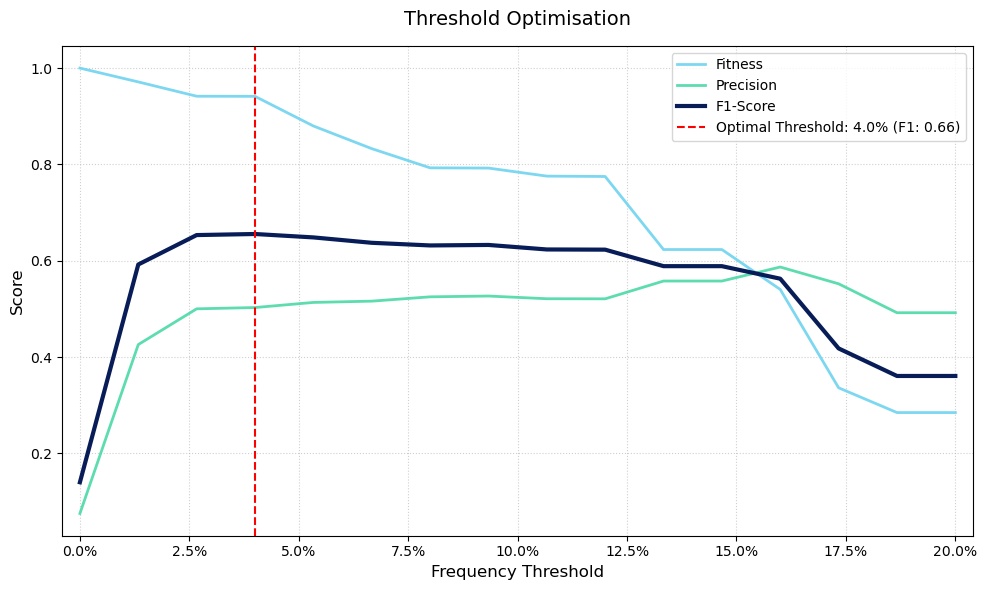

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_res['Threshold'], df_res['Fitness'], label='Fitness', color="#6fd3ef", alpha=0.9, linewidth=2)
plt.plot(df_res['Threshold'], df_res['Precision'], label='Precision', color="#4ad9a7", alpha=0.9, linewidth=2)
plt.plot(df_res['Threshold'], df_res['F1-Score'], label='F1-Score', color='#081d58', linewidth=3)

opt_idx = df_res['F1-Score'].idxmax()
opt_t = df_res.loc[opt_idx, 'Threshold']
opt_f1 = df_res.loc[opt_idx, 'F1-Score']
    
plt.axvline(opt_t, color='red', linestyle='--', label=f'Optimal Threshold: {opt_t:.1%} (F1: {opt_f1:.2f})')
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{x*100:.1f}%' for x in ticks])
    
plt.title("Threshold Optimisation", fontsize=14, pad=15)
plt.xlabel("Frequency Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.margins(x=0.02)
plt.tight_layout()
plt.savefig("files/threshold_optimization.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Finalise role permissions

In [ ]:
# Apply threshold
threshold = opt_t.astype(float)
opt_permissions = (
    (role_act_freq > threshold)
    .stack()
    .loc[lambda x: x]
    .reset_index()[['Role', 'Activity']]
)

Check for orphaned activities and assign them manually

In [ ]:
all_activities = set(df_filtered['Activity'].unique())
activities_with_roles = set(opt_permissions['Activity'].unique())

orphaned_activities = all_activities - activities_with_roles

print(f"Number of orphaned activities: {len(orphaned_activities)}")
if orphaned_activities:
    for act in orphaned_activities:
        print(act)

Number of orphaned activities: 3
W_Call incomplete files
W_Call after offers
W_Handle leads


In [ ]:
manual_permission = pd.DataFrame([{'Role': 'Role_2', 'Activity': 'W_Call incomplete files'}, 
                                  {'Role': 'Role_3', 'Activity': 'W_Call incomplete files'}, 
                                  {'Role': 'Role_1', 'Activity': 'W_Call after offers'}, 
                                  {'Role': 'Role_2', 'Activity': 'W_Call after offers'}, 
                                  {'Role': 'Role_1', 'Activity': 'W_Handle leads'}])

Define final permissions

In [ ]:
final_permissions = pd.concat([opt_permissions, manual_permission], ignore_index=True)
final_permissions = final_permissions.drop_duplicates()

final_permissions.to_csv('role_permissions.csv', index=False)
print(f"role_permissions.csv created (Threshold: {threshold*100}%).")

role_permissions.csv created (Threshold: 4.0%).


In [ ]:
print("\n--- Summary ---")
print(f"Total Resources: {len(resource_roles)}")
print(f"Discovered Roles: {resource_roles['Role'].nunique()}")
print(f"Total Permissions: {len(final_permissions)}")
print(f"Distinct Permissions: {final_permissions['Activity'].nunique()}")

# Sample permissions
sample_role = 'Role_0'
print(f"\nPermissions for {sample_role}:")
print(final_permissions[final_permissions['Role'] == sample_role]['Activity'].tolist())


--- Summary ---
Total Resources: 144
Discovered Roles: 6
Total Permissions: 40
Distinct Permissions: 22

Permissions for Role_0:
['A_Cancelled', 'A_Concept', 'A_Create Application', 'A_Submitted', 'O_Cancelled']


In [ ]:
df_merged = pd.merge(df_filtered, resource_roles, on='Resource')
final_fitness = calculate_fitness(df_merged, final_permissions)
final_precision = calculate_precision(df_merged, resource_roles, final_permissions)
final_f1 = calculate_f1_score(final_fitness, final_precision)
print(f"Fitness:   {final_fitness:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"F1-Score:  {final_f1:.4f}")

Fitness:   0.9494
Precision: 0.4965
F1-Score:  0.6520
